# Sentiment Analysis on Twitter Data using LSTM

## Week 3 – Deep Learning (LSTM)

### Objective

The objective of this notebook is to build a Deep Learning based Sentiment Analysis model using Long Short-Term Memory (LSTM) networks.

Unlike classical machine learning models that rely on TF-IDF features, the LSTM model learns contextual relationships between words by processing the sequence of text.

This notebook includes:

- Loading the cleaned dataset
- Label encoding
- Text tokenization
- Sequence padding
- Train-Test split
- Building the LSTM architecture
- Model training
- Performance evaluation
- Model inference
- Saving the trained model for deployment

The trained model will later be integrated into the Streamlit dashboard developed in Week 4.

# Step 1 : Import Required Libraries

The first step is to import all required Python libraries.

These libraries are used for:

- Data manipulation
- Text preprocessing
- Tokenization
- Deep Learning
- Model evaluation
- Saving trained models

In [57]:
import warnings
warnings.filterwarnings("ignore")

import re
import string
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Step 2 : Load the Cleaned Dataset

The cleaned dataset generated during Week 1 is loaded for deep learning.

The dataset contains:

- Original tweet
- Cleaned tweet
- Sentiment label

Only the cleaned tweet and sentiment label are required for training the LSTM model.

In [58]:
df = pd.read_csv("../processed_data/cleaned_tweets.csv")

df.head()

,tweet,clean_tweet,sentiment
0,@VirginAmerica What @dhepburn said.,said,neutral
1,@VirginAmerica plus you've added commercials t...,plus youve added commercial experience tacky,positive
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip,neutral
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...,negative
4,@VirginAmerica and it's a really big bad thing...,really big bad thing,negative


# Step 3 : Explore the Dataset

Before training the model, it is important to verify that the dataset has been loaded correctly.

The following checks are performed:

- Dataset shape
- Column names
- Missing values
- Sentiment distribution

In [59]:
print("Dataset Shape :", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

Dataset Shape : (14452, 3)

Columns:
Index(['tweet', 'clean_tweet', 'sentiment'], dtype='str')

Missing Values:
tweet           0
clean_tweet    20
sentiment       0
dtype: int64

Sentiment Distribution:
sentiment
negative    9087
neutral     3067
positive    2298
Name: count, dtype: int64


In [60]:
df.head()

,tweet,clean_tweet,sentiment
0,@VirginAmerica What @dhepburn said.,said,neutral
1,@VirginAmerica plus you've added commercials t...,plus youve added commercial experience tacky,positive
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip,neutral
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...,negative
4,@VirginAmerica and it's a really big bad thing...,really big bad thing,negative


# Step 4 : Encode Sentiment Labels

Machine Learning and Deep Learning models require numerical labels instead of text labels.

The sentiment classes are converted into integer values using Label Encoding.

Mapping:

- Negative → 0
- Neutral → 1
- Positive → 2

In [61]:
encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["sentiment"])

print("Label Mapping")

for sentiment, label in zip(encoder.classes_, encoder.transform(encoder.classes_)):
    print(f"{sentiment} --> {label}")

Label Mapping
negative --> 0
neutral --> 1
positive --> 2


In [62]:
df[["sentiment","label"]].head(10)

,sentiment,label
0,neutral,1
1,positive,2
2,neutral,1
3,negative,0
4,negative,0
5,negative,0
6,positive,2
7,neutral,1
8,positive,2
9,positive,2


# Step 5 : Prepare Features and Labels

The cleaned tweet text is selected as the input feature.

The encoded sentiment labels are selected as the target variable.

In [63]:
X = df["clean_tweet"].astype(str)

y = df["label"]

print("Total Tweets :", len(X))
print("Total Labels :", len(y))

Total Tweets : 14452
Total Labels : 14452


# Step 6 : Tokenization

Deep Learning models cannot understand raw text directly.

The Tokenizer converts each word into a unique integer index.

Example:

"I love AI"

↓

[15, 87, 312]

Only the most frequent 10,000 words are retained to reduce model complexity.

In [67]:
print(df["clean_tweet"].isnull().sum())

20


In [68]:
print(df["clean_tweet"].dtype)

str


In [69]:
df[df["clean_tweet"].isnull()]

,tweet,clean_tweet,sentiment,label
779,@united you too!,NaN,positive,2
1641,@united now this http://t.co/uygeW2Nosr,NaN,negative,0
3498,@united I have.,NaN,neutral,1
3973,@united @annricord both!,NaN,neutral,1
5440,@SouthwestAir it was 3472,NaN,neutral,1
5638,@SouthwestAir is that @MurraySawChuck,NaN,neutral,1
6271,@SouthwestAir No I have not.,NaN,negative,0
6491,@SouthwestAir Awwweesssooomee!,NaN,positive,2
6871,@JetBlue or she ;),NaN,neutral,1
6921,@JetBlue @BucketObolts Same,NaN,neutral,1


In [70]:
# Remove rows where clean_tweet is missing
df = df.dropna(subset=["clean_tweet"])

# Convert all tweets to string
df["clean_tweet"] = df["clean_tweet"].astype(str)

X = df["clean_tweet"]
y = df["label"]

In [71]:
print(X.isnull().sum())
print(X.dtype)

0
str


In [72]:
VOCAB_SIZE = 10000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X)

In [73]:
print("Vocabulary Size :", len(tokenizer.word_index))

Vocabulary Size : 11836


# Step 7 : Convert Text into Integer Sequences

Each cleaned tweet is transformed into a sequence of integer tokens.

These sequences preserve the order of words, allowing the LSTM network to learn contextual information.

In [74]:
sequences = tokenizer.texts_to_sequences(X)

print("First Tweet")
print(X.iloc[0])

print("\nSequence")
print(sequences[0])

First Tweet
said

Sequence
[132]


# Step 8 : Pad Sequences

Tweets have different lengths.

LSTM models require all input sequences to have equal length.

Padding is applied after the end of shorter sequences.

Maximum sequence length:

50 words

In [75]:
MAX_LENGTH = 50

X_pad = pad_sequences(
    sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print(X_pad.shape)

(14432, 50)


# Step 9 : Train-Test Split

The dataset is divided into:

- Training Set (80%)
- Testing Set (20%)

Stratified sampling is used to preserve the sentiment distribution across both sets.

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [77]:
print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (11545, 50)
Testing Shape  : (2887, 50)


In [98]:
print(y_pred_prob[:10])

[[0.35708007 0.33625692 0.30666295]
 [0.35708037 0.3362568  0.3066628 ]
 [0.35708177 0.33625564 0.3066626 ]
 [0.3570774  0.33625686 0.3066657 ]
 [0.35707998 0.33625713 0.30666292]
 [0.35707784 0.3362575  0.30666468]
 [0.35708007 0.33625656 0.30666333]
 [0.3570789  0.3362572  0.3066639 ]
 [0.35707888 0.33625698 0.30666408]
 [0.35707954 0.336257   0.30666345]]


# Step 10 : Verify Training Data

Before building the LSTM model, verify that:

- Training data has the correct dimensions.
- Testing data has the correct dimensions.
- All three sentiment classes are present in both datasets.

In [78]:
print("Unique Training Labels :", np.unique(y_train))
print("Unique Testing Labels  :", np.unique(y_test))

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Unique Training Labels : [0 1 2]
Unique Testing Labels  : [0 1 2]

Training Samples : 11545
Testing Samples  : 2887


# Step 11 : Build an Improved Bidirectional LSTM Model

A Bidirectional LSTM is used to capture contextual information from both forward and backward directions of a sentence.

Model Architecture:

- Embedding Layer
- Spatial Dropout Layer
- Bidirectional LSTM Layer
- Dense Hidden Layer
- Batch Normalization
- Dropout Layer
- Softmax Output Layer

This architecture generally performs better than a simple LSTM for sentiment analysis tasks.

In [103]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional,
    SpatialDropout1D,
    BatchNormalization
)

model = Sequential()

model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LENGTH
    )
)

model.add(SpatialDropout1D(0.3))

model.add(
    Bidirectional(
        LSTM(128)
    )
)

model.add(Dropout(0.4))

model.add(Dense(128, activation="relu"))

model.add(BatchNormalization())

model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))

model.add(Dense(3, activation="softmax"))

In [104]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Step 12 : Compile the Model

The model is compiled using:

- Adam Optimizer
- Sparse Categorical Crossentropy
- Accuracy Metric

A reduced learning rate improves convergence stability.

In [106]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=0.0005
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [107]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "../models/best_lstm.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [108]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5297815712187959), np.int64(1): np.float64(1.5733169801035705), np.int64(2): np.float64(2.097184377838329)}


# Step 15 : Train the Improved LSTM Model

The model is trained using:

- Class Weights
- Early Stopping
- Model Checkpoint
- Validation Dataset

The best-performing model is automatically saved.

In [109]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        checkpoint
    ],
    verbose=1
)

Epoch 1/20
180/181 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5809 - loss: 0.9263
Epoch 1: val_accuracy improved from None to 0.74368, saving model to ../models/best_lstm.keras

Epoch 1: finished saving model to ../models/best_lstm.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - accuracy: 0.5815 - loss: 0.9254 - val_accuracy: 0.7437 - val_loss: 0.9476
Epoch 2/20
180/181 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7490 - loss: 0.6143
Epoch 2: val_accuracy improved from 0.74368 to 0.77866, saving model to ../models/best_lstm.keras

Epoch 2: finished saving model to ../models/best_lstm.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - accuracy: 0.7492 - loss: 0.6141 - val_accuracy: 0.7787 - val_loss: 0.7574
Epoch 3/20
180/181 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8203 - loss: 0.4519
Epoch 3: val_accuracy improved from 0.77866 to 0.78490, saving model to ../models/best_lstm.keras

Epoch 3: finished saving model to ../models/best_lstm.keras
181/181 ━━━━━━━━━━━━━━━━━━━

In [110]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Accuracy:", accuracy)
print("Loss:", loss)

Accuracy: 0.7848978042602539
Loss: 0.5637431740760803


In [111]:
y_pred_prob = model.predict(
    X_test,
    verbose=0
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

In [112]:
import pandas as pd

print("Predicted")

print(pd.Series(y_pred).value_counts())

print()

print("Actual")

print(pd.Series(y_test).value_counts())

Predicted
0    2014
1     481
2     392
Name: count, dtype: int64

Actual
label
0    1817
1     611
2     459
Name: count, dtype: int64


In [113]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ]
    )
)


              precision    recall  f1-score   support

    Negative       0.82      0.91      0.87      1817
     Neutral       0.64      0.51      0.57       611
    Positive       0.76      0.65      0.70       459

    accuracy                           0.78      2887
   macro avg       0.74      0.69      0.71      2887
weighted avg       0.78      0.78      0.78      2887



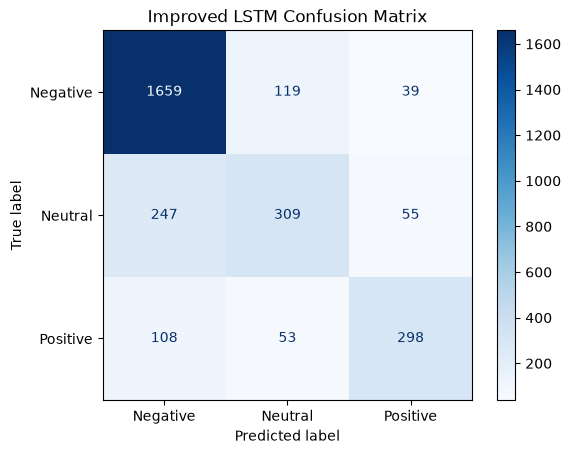

In [114]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

disp.plot(cmap="Blues")

plt.title("Improved LSTM Confusion Matrix")

plt.show()

In [115]:
model.save("../models/lstm_model.keras")

In [116]:
import joblib

joblib.dump(
    tokenizer,
    "../models/tokenizer.pkl"
)

['../models/tokenizer.pkl']

# Step 16: Model Evaluation

After training, the LSTM model is evaluated on the unseen testing dataset.

The evaluation provides:

- Test Accuracy
- Test Loss

These metrics indicate how well the model generalizes to unseen tweets.

In [117]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("=" * 50)
print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")
print("=" * 50)

Test Accuracy : 78.49%
Test Loss     : 0.5637


# Step 17: Generate Predictions

The trained LSTM model predicts the sentiment class for each tweet in the testing dataset.

The class with the highest probability is selected as the final prediction.

In [118]:
import numpy as np

y_pred_prob = model.predict(
    X_test,
    verbose=0
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

print("Prediction Shape:", y_pred.shape)

Prediction Shape: (2887,)


# Step 18: Compare Label Distribution

The distribution of predicted labels is compared with the actual testing labels.

This helps identify whether the model is biased toward a particular sentiment class.

In [119]:
import pandas as pd

print("Actual Label Distribution")
print(pd.Series(y_test).value_counts().sort_index())

print("\nPredicted Label Distribution")
print(pd.Series(y_pred).value_counts().sort_index())

Actual Label Distribution
label
0    1817
1     611
2     459
Name: count, dtype: int64

Predicted Label Distribution
0    2014
1     481
2     392
Name: count, dtype: int64


# Step 19: Classification Report

The classification report provides detailed evaluation metrics including:

- Precision
- Recall
- F1-Score
- Support

These metrics are calculated separately for:

- Negative
- Neutral
- Positive

In [120]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.82      0.91      0.87      1817
     Neutral       0.64      0.51      0.57       611
    Positive       0.76      0.65      0.70       459

    accuracy                           0.78      2887
   macro avg       0.74      0.69      0.71      2887
weighted avg       0.78      0.78      0.78      2887



# Step 20: Confusion Matrix

The confusion matrix visualizes the number of correctly and incorrectly classified tweets for each sentiment category.

A strong diagonal indicates good classification performance.

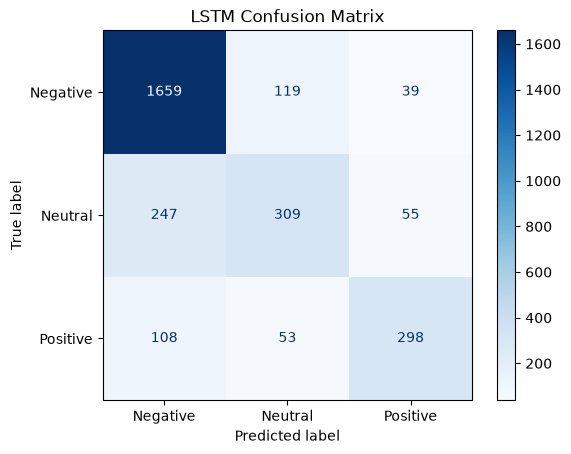

In [121]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

disp.plot(cmap="Blues")

plt.title("LSTM Confusion Matrix")

plt.savefig(
    "../images/lstm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Step 21: Save the Trained LSTM Model

The trained LSTM model is saved in Keras format for future use.

This model will be loaded directly by the Streamlit application during deployment, eliminating the need for retraining.

In [122]:
model.save("../models/lstm_model.keras")

print("✅ LSTM model saved successfully.")

✅ LSTM model saved successfully.


# Step 22: Save the Tokenizer

The tokenizer used during training is saved using Joblib.

Saving the tokenizer ensures that user input in the web application is converted into sequences exactly the same way as the training data.

In [123]:
import joblib

joblib.dump(
    tokenizer,
    "../models/tokenizer.pkl"
)

print("✅ Tokenizer saved successfully.")

✅ Tokenizer saved successfully.


# Step 23: Training Accuracy Graph

The graph below compares training accuracy and validation accuracy over all epochs.

It helps visualize how the model learned during training and whether overfitting occurred.

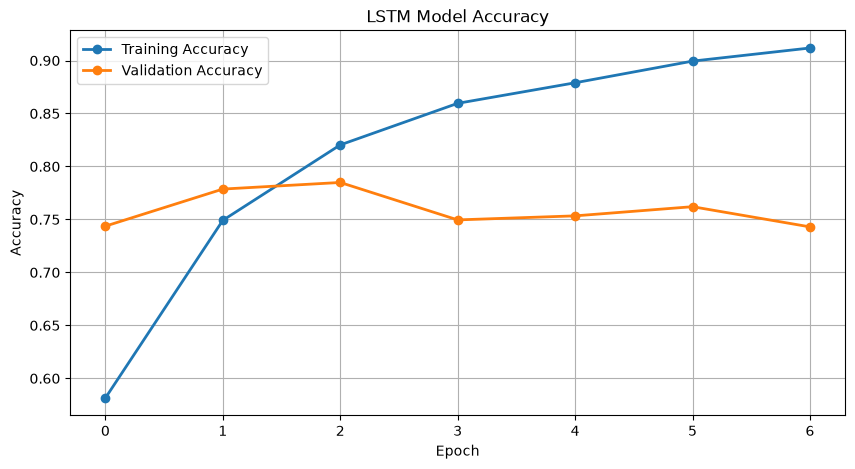

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="Validation Accuracy"
)

plt.title("LSTM Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.savefig(
    "../images/lstm_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Step 24: Training Loss Graph

The loss graph compares training loss and validation loss during training.

A decreasing loss indicates that the model is learning meaningful patterns from the dataset.

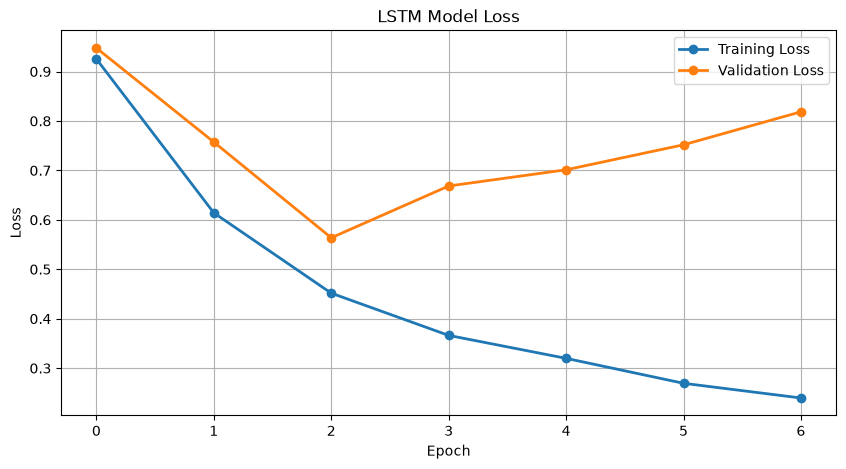

In [125]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.title("LSTM Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.savefig(
    "../images/lstm_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Step 25: Model Comparison

The performance of the Deep Learning model is compared with the Machine Learning models developed in Week 2.

The comparison includes:

- Logistic Regression
- Naive Bayes
- LSTM

This comparison helps determine the best-performing model for sentiment classification.

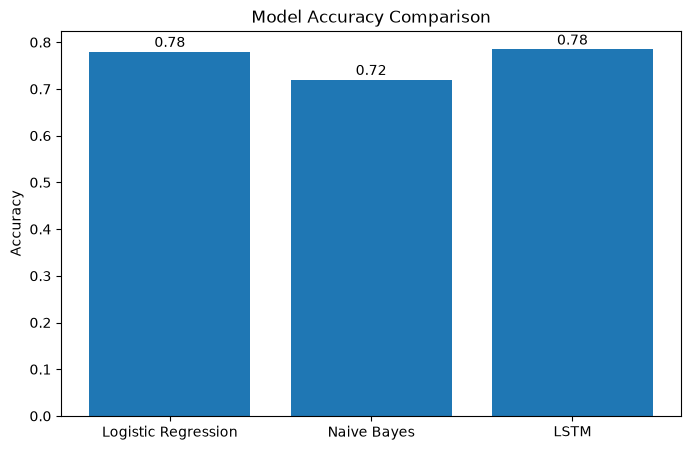

In [128]:
models = [
    "Logistic Regression",
    "Naive Bayes",
    "LSTM"
]

accuracy = [
    0.78,     #  Logistic Regression accuracy
    0.72,     #  Naive Bayes accuracy
    0.7849    # LSTM test accuracy from Step 16
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracy)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.2f}",
        ha="center"
    )

plt.savefig(
    "../images/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Week 3 Summary

During Week 3, a Deep Learning-based sentiment analysis model was developed using Long Short-Term Memory (LSTM) networks.

### Tasks Completed

- Loaded the cleaned Twitter dataset
- Performed text tokenization
- Created a vocabulary
- Converted tweets into integer sequences
- Applied sequence padding
- Split the dataset into training and testing sets
- Designed the LSTM architecture
- Compiled the model using the Adam optimizer
- Trained the model with Early Stopping and Model Checkpoint
- Evaluated model performance
- Generated prediction results
- Created the classification report
- Generated the confusion matrix
- Saved the trained LSTM model
- Saved the tokenizer
- Generated training accuracy and loss graphs
- Compared Deep Learning performance with Machine Learning models

### Outcome

The trained LSTM model is ready to be integrated into the Streamlit web application developed in Week 4.

# Week 4: Streamlit Web Application Development

## Objective

The objective of Week 4 is to deploy the trained LSTM sentiment analysis model through an interactive Streamlit web application.

The application allows users to enter any tweet and instantly receive:

- Predicted sentiment
- Confidence score
- Probability distribution
- Visual analytics

The web application uses the trained LSTM model and tokenizer saved during Week 3.